# Notebook 03: análisis espacial

**RSNA 2022 Cervical Spine Fracture Detection**

Este notebook cuantifica la cobertura y geometría de las anotaciones espaciales.
Está preparado para ejecutarse en Kaggle y generar resultados reproducibles.
Cada figura se exporta automáticamente a la carpeta figures con 200 dpi.

## 0. Preparación

Adjunta a este notebook el dataset de la competencia. Si el repositorio no se
encuentra en /kaggle/working, sube también la carpeta src o ajusta PROJECT_ROOT.

In [15]:
from pathlib import Path
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.patches import Rectangle
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

KAGGLE = Path("/kaggle/input").exists()
PROJECT_ROOT = Path("/kaggle/working") if KAGGLE else Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

dataset_candidates = [
    Path("/kaggle/input/rsna-2022-cervical-spine-fracture-detection"),
    Path("/kaggle/input/competitions/rsna-2022-cervical-spine-fracture-detection"),
    PROJECT_ROOT / "dataset",
]
if KAGGLE:
    # Admite nombres personalizados de Input sin recorrer los 700 mil DICOM.
    dataset_candidates += [p.parent for p in Path("/kaggle/input").glob("*/train.csv")]
    dataset_candidates += [p.parent for p in Path("/kaggle/input").glob("*/*/train.csv")]
BASE = next((p for p in dataset_candidates
             if (p / "train.csv").is_file()
             and (p / "train_bounding_boxes.csv").is_file()), None)
if BASE is None:
    mounted = [p.name for p in Path("/kaggle/input").iterdir()] if KAGGLE else []
    raise FileNotFoundError(
        "No se encontró el dataset RSNA 2022. En Kaggle usa Add Input > "
        "Competition Data > RSNA 2022 Cervical Spine Fracture Detection y "
        f"vuelve a ejecutar. Inputs montados actualmente: {mounted or 'ninguno'}"
    )
TRAIN_IMAGES = BASE / "train_images"
SEGMENTATIONS = BASE / "segmentations"
FIGURES = Path("/kaggle/working/figures") if KAGGLE else PROJECT_ROOT / "figures"
DATA_OUT = Path("/kaggle/working/data") if KAGGLE else PROJECT_ROOT / "data"
FIGURES.mkdir(parents=True, exist_ok=True)
DATA_OUT.mkdir(parents=True, exist_ok=True)

def guardar(fig, nombre):
    path = FIGURES / nombre
    fig.savefig(path, dpi=200, bbox_inches="tight", facecolor="white")
    print(f"Figura guardada: {path}")

print(f"Entorno: {'Kaggle' if KAGGLE else 'local'}")
print(f"Dataset: {BASE}")

import nibabel as nib

def cargar_segmentacion(uid, segmentations_dir=SEGMENTATIONS):
    """Carga y orienta la máscara como volumen axial (z, y, x)."""
    paths = [segmentations_dir / f"{uid}.nii", segmentations_dir / f"{uid}.nii.gz"]
    path = next((p for p in paths if p.exists()), None)
    if path is None:
        raise FileNotFoundError(f"No existe segmentación para {uid}")
    nii = nib.load(path)
    seg = np.asanyarray(nii.dataobj)
    return np.rint(np.transpose(seg, (2, 1, 0))[:, ::-1, :]).astype(np.uint8)

train = pd.read_csv(BASE / "train.csv")
bbox = pd.read_csv(BASE / "train_bounding_boxes.csv")

def segmentation_uid(path):
    name = path.name
    return name[:-7] if name.endswith(".nii.gz") else path.stem

seg_paths = sorted(list(SEGMENTATIONS.glob("*.nii")) + list(SEGMENTATIONS.glob("*.nii.gz")))
seg_uids = {segmentation_uid(path) for path in seg_paths}

print(f"Estudios de entrenamiento: {train.StudyInstanceUID.nunique():,}")
print(f"Filas de bounding boxes: {len(bbox):,}")
print(f"Estudios con bounding box: {bbox.StudyInstanceUID.nunique():,}")
print(f"Estudios con segmentación: {len(seg_uids):,}")

Entorno: Kaggle
Dataset: /kaggle/input/competitions/rsna-2022-cervical-spine-fracture-detection
Estudios de entrenamiento: 2,019
Filas de bounding boxes: 7,217
Estudios con bounding box: 235
Estudios con segmentación: 87


## 1. Cobertura de bounding boxes

Las cajas no son una etiqueta exhaustiva del conjunto: solo localizan lesiones en
una fracción de los estudios. Por ello se reportan tanto respecto de todo train
como respecto de los casos positivos.

In [16]:
n_total = train["StudyInstanceUID"].nunique()
n_positive = train.loc[train["patient_overall"].eq(1), "StudyInstanceUID"].nunique()
bbox_uids = set(bbox["StudyInstanceUID"].astype(str))
n_bbox = len(bbox_uids)
n_bbox_positive = len(bbox_uids & set(train.loc[train.patient_overall.eq(1), "StudyInstanceUID"].astype(str)))

coverage = pd.DataFrame({
    "métrica": ["Estudios con caja / train", "Estudios con caja / positivos"],
    "numerador": [n_bbox, n_bbox_positive],
    "denominador": [n_total, n_positive],
})
coverage["porcentaje"] = 100 * coverage["numerador"] / coverage["denominador"]
display(coverage.style.format({"porcentaje": "{:.2f}%"}))
display(Markdown(
    f"**Interpretación.** Las cajas cubren {n_bbox:,} de {n_total:,} estudios "
    f"({100*n_bbox/n_total:.2f}%) y {n_bbox_positive:,} de {n_positive:,} casos "
    f"positivos ({100*n_bbox_positive/n_positive:.2f}%). En consecuencia, la ausencia "
    "de una caja no debe interpretarse como ausencia de fractura."
))

,métrica,numerador,denominador,porcentaje
0,Estudios con caja / train,235,2019,11.64%
1,Estudios con caja / positivos,235,961,24.45%


**Interpretación.** Las cajas cubren 235 de 2,019 estudios (11.64%) y 235 de 961 casos positivos (24.45%). En consecuencia, la ausencia de una caja no debe interpretarse como ausencia de fractura.

## 2. Tamaño y forma de las lesiones anotadas

,width,height,area_px,area_pct_512,aspect_ratio
count,7217.000000,7217.000000,7217.000000,7217.000000,7217.000000
mean,100.916069,78.787244,9628.654017,3.673040,1.358103
std,54.948263,42.884778,9908.342406,3.779733,0.560900
min,11.000000,10.632710,126.621009,0.048302,0.306824
1%,19.652328,19.044323,399.269222,0.152309,0.525452
25%,57.565400,47.411080,2933.269780,1.118954,0.972670
50%,89.307160,70.000000,6331.701409,2.415352,1.245902
75%,133.712010,99.000000,12521.783740,4.776681,1.620690
95%,208.330246,162.223548,28888.085257,11.019930,2.378245
99%,250.545084,210.532772,47301.447265,18.044070,3.207916


Figura guardada: /kaggle/working/figures/03_area_y_forma_bounding_boxes.png


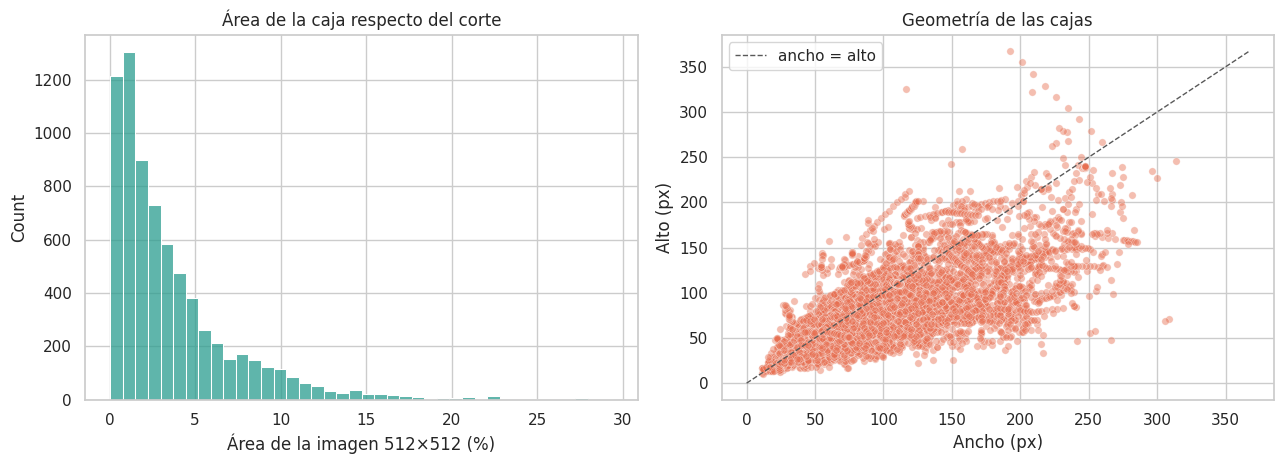

**Hallazgo central.** La región delimitada por la caja ocupa una mediana de **2.415%** del corte y el percentil 95 alcanza 11.020%. La caja incluye la lesión y tejido circundante, por lo que constituye un límite superior aproximado de su tamaño. Aun así, la región de interés es pequeña frente al campo de visión, lo que respalda localizar o recortar la vértebra antes de clasificar la fractura.

In [17]:
bbox = bbox.copy()
bbox["area_px"] = bbox["width"] * bbox["height"]
bbox["area_pct_512"] = 100 * bbox["area_px"] / (512 * 512)
bbox["aspect_ratio"] = bbox["width"] / bbox["height"].replace(0, np.nan)

display(bbox[["width", "height", "area_px", "area_pct_512", "aspect_ratio"]].describe(
    percentiles=[.01, .25, .5, .75, .95, .99]
))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.histplot(bbox["area_pct_512"], bins=40, ax=axes[0], color="#2a9d8f")
axes[0].set(title="Área de la caja respecto del corte", xlabel="Área de la imagen 512×512 (%)")
sns.scatterplot(data=bbox, x="width", y="height", alpha=.45, s=28, ax=axes[1], color="#e76f51")
limit = max(bbox["width"].max(), bbox["height"].max())
axes[1].plot([0, limit], [0, limit], "--", color="0.35", linewidth=1, label="ancho = alto")
axes[1].set(title="Geometría de las cajas", xlabel="Ancho (px)", ylabel="Alto (px)")
axes[1].legend()
fig.tight_layout()
guardar(fig, "03_area_y_forma_bounding_boxes.png")
plt.show()

median_area = bbox["area_pct_512"].median()
p95_area = bbox["area_pct_512"].quantile(.95)
display(Markdown(
    f"**Hallazgo central.** La región delimitada por la caja ocupa una mediana de "
    f"**{median_area:.3f}%** del corte y el percentil 95 alcanza {p95_area:.3f}%. "
    "La caja incluye la lesión y tejido circundante, por lo que constituye un límite "
    "superior aproximado de su tamaño. Aun así, la región de interés es pequeña frente "
    "al campo de visión, lo que respalda localizar o recortar la vértebra antes de "
    "clasificar la fractura."
))

## 3. Número de cajas por estudio

Figura guardada: /kaggle/working/figures/03_cajas_por_estudio.png


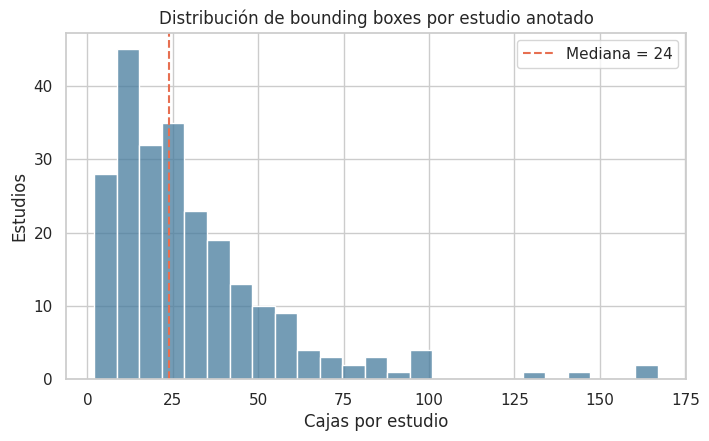

,count,mean,std,min,25%,50%,75%,max
n_boxes,235.0,30.710638,26.022699,2.0,14.0,24.0,38.0,167.0


**Interpretación.** Un estudio anotado tiene una mediana de 24 cajas y un máximo de 167. La distribución presenta una cola derecha: algunos casos fueron anotados en muchos cortes consecutivos. Por ello, el número de cajas no equivale al número de fracturas independientes.

In [18]:
boxes_per_study = bbox.groupby("StudyInstanceUID").size().rename("n_boxes")
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(boxes_per_study, bins=25, color="#457b9d", ax=ax)
ax.axvline(boxes_per_study.median(), color="#e76f51", linestyle="--",
           label=f"Mediana = {boxes_per_study.median():.0f}")
ax.set(title="Distribución de bounding boxes por estudio anotado",
       xlabel="Cajas por estudio", ylabel="Estudios")
ax.legend()
guardar(fig, "03_cajas_por_estudio.png")
plt.show()

display(boxes_per_study.describe().to_frame().T)
display(Markdown(
    f"**Interpretación.** Un estudio anotado tiene una mediana de "
    f"{boxes_per_study.median():.0f} cajas y un máximo de {boxes_per_study.max():.0f}. "
    "La distribución presenta una cola derecha: algunos casos fueron anotados en "
    "muchos cortes consecutivos. Por ello, el número de cajas no equivale al número "
    "de fracturas independientes."
))

## 4. Posición de la lesión dentro del volumen

Se usa la definición solicitada slice_number / n_slices. Si no existe el caché
meta_train.csv, se cuentan únicamente los archivos de los estudios con caja; no se
leen sus píxeles.

Contando cortes de estudios con caja:   0%|          | 0/235 [00:00<?, ?it/s]

Figura guardada: /kaggle/working/figures/03_posicion_relativa_lesion.png


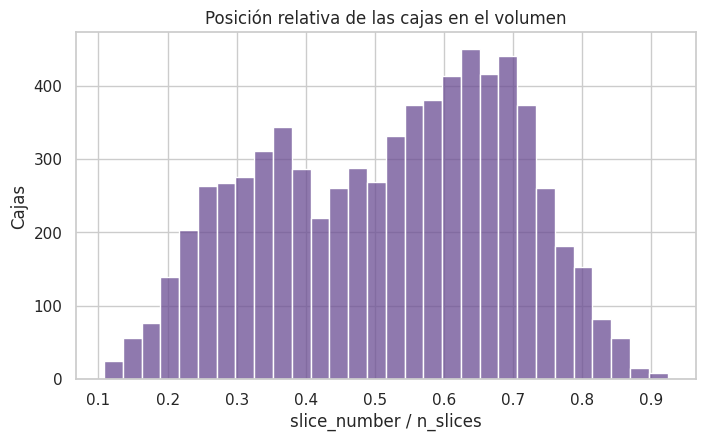

**Interpretación.** La posición relativa mediana es 0.543. Se excluyeron 0 registros fuera de [0, 1] o sin conteo. Esta razón describe ubicación dentro de la pila, no una coordenada física; el sentido craneocaudal puede invertirse entre estudios.

In [19]:
meta_candidates = [DATA_OUT / "meta_train.csv", PROJECT_ROOT / "data" / "meta_train.csv",
                   Path("/kaggle/working/dicom_metadata.csv")]
meta_path = next((path for path in meta_candidates if path.exists()), None)

if meta_path is not None:
    meta = pd.read_csv(meta_path)
    slice_counts = meta[["StudyInstanceUID", "n_slices"]].copy()
    slice_counts["StudyInstanceUID"] = slice_counts["StudyInstanceUID"].astype(str)
    print(f"Conteos cargados desde {meta_path}")
else:
    counts = []
    for uid in tqdm(sorted(bbox_uids), desc="Contando cortes de estudios con caja"):
        study_dir = TRAIN_IMAGES / uid
        counts.append((uid, sum(1 for _ in study_dir.glob("*.dcm"))))
    slice_counts = pd.DataFrame(counts, columns=["StudyInstanceUID", "n_slices"])

bbox_pos = bbox.assign(StudyInstanceUID=bbox["StudyInstanceUID"].astype(str)).merge(
    slice_counts, on="StudyInstanceUID", how="left", validate="many_to_one"
)
bbox_pos["posicion_relativa"] = bbox_pos["slice_number"] / bbox_pos["n_slices"]
valid_position = bbox_pos["posicion_relativa"].between(0, 1, inclusive="both")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(bbox_pos.loc[valid_position, "posicion_relativa"], bins=30, color="#6a4c93", ax=ax)
ax.set(title="Posición relativa de las cajas en el volumen", xlabel="slice_number / n_slices", ylabel="Cajas")
guardar(fig, "03_posicion_relativa_lesion.png")
plt.show()

median_position = bbox_pos.loc[valid_position, "posicion_relativa"].median()
display(Markdown(
    f"**Interpretación.** La posición relativa mediana es {median_position:.3f}. "
    f"Se excluyeron {int((~valid_position).sum())} registros fuera de [0, 1] o sin "
    "conteo. Esta razón describe ubicación dentro de la pila, no una coordenada física; "
    "el sentido craneocaudal puede invertirse entre estudios."
))

## 5. Solapamiento de los dos tipos de anotación espacial

Figura guardada: /kaggle/working/figures/03_solapamiento_anotaciones.png


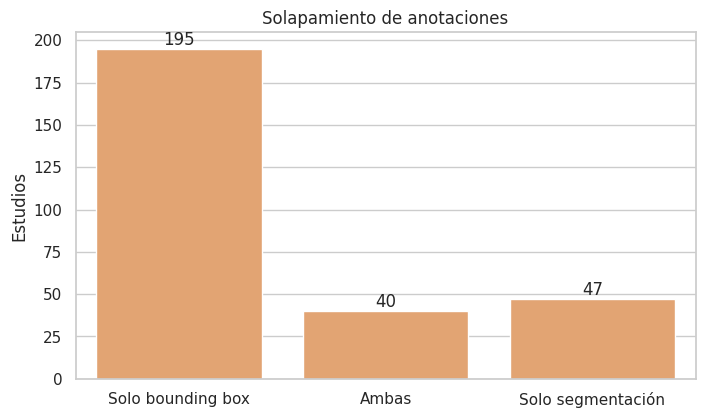

**Interpretación.** Hay **40** estudios con ambos tipos de anotación, 195 solo con cajas y 47 solo con segmentación. Solo la intersección permite validar directamente la localización de la fractura contra la anatomía vertebral segmentada.

In [20]:
both = bbox_uids & seg_uids
overlap_counts = pd.Series({
    "Solo bounding box": len(bbox_uids - seg_uids),
    "Ambas": len(both),
    "Solo segmentación": len(seg_uids - bbox_uids),
})
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=overlap_counts.index, y=overlap_counts.values, color="#f4a261", ax=ax)
ax.set(title="Solapamiento de anotaciones", xlabel="", ylabel="Estudios")
ax.bar_label(ax.containers[0])
guardar(fig, "03_solapamiento_anotaciones.png")
plt.show()

display(Markdown(
    f"**Interpretación.** Hay **{len(both)}** estudios con ambos tipos de anotación, "
    f"{len(bbox_uids-seg_uids)} solo con cajas y {len(seg_uids-bbox_uids)} solo con "
    "segmentación. Solo la intersección permite validar directamente la localización "
    "de la fractura contra la anatomía vertebral segmentada."
))

## 6. Volumen de las segmentaciones por vértebra

El resultado se cachea porque cargar los NIfTI puede tardar varios minutos.
Los valores son conteos de voxeles, no mm³; para volumen físico sería necesario
multiplicar por el volumen de voxel indicado en la cabecera.

El caché anterior no contiene el detalle T1–T12; se recalculará.


Midiendo segmentaciones:   0%|          | 0/87 [00:00<?, ?it/s]

Caché guardado: /kaggle/working/data/volumen_segmentaciones.csv; errores: 0
Figura guardada: /kaggle/working/figures/03_volumen_medio_vertebras.png


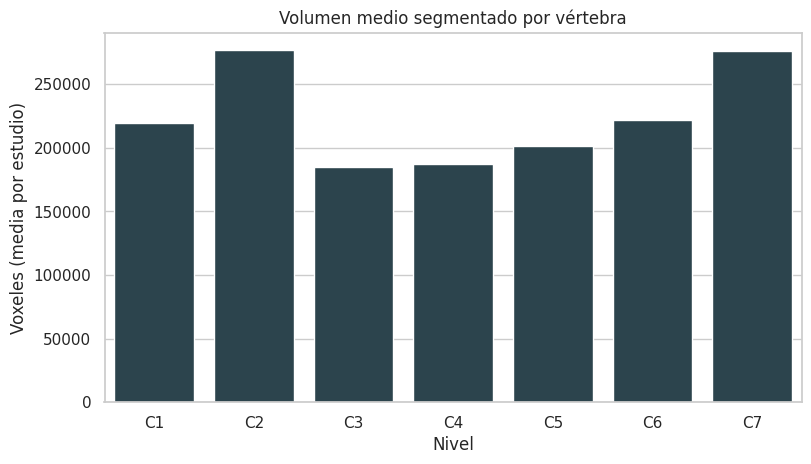

,count,mean,std,min,25%,50%,75%,max
C1_voxels,87.0,219429.574713,136360.625951,34952.0,128861.5,209198.0,257934.0,948188.0
C2_voxels,87.0,276745.919540,166369.737173,40867.0,169879.0,266129.0,344941.0,1158180.0
C3_voxels,87.0,185309.080460,110238.794968,29754.0,114501.5,167125.0,235106.5,723680.0
C4_voxels,87.0,187189.459770,114978.583274,28912.0,110103.5,165777.0,240655.0,735445.0
C5_voxels,87.0,201616.413793,123624.260828,28346.0,120449.5,181527.0,255670.5,804636.0
C6_voxels,87.0,221985.091954,136245.038574,34804.0,131754.0,199312.0,282209.0,915168.0
C7_voxels,87.0,276516.494253,159704.693958,42904.0,167384.5,261470.0,360626.5,988400.0


,estudios_pct
T1,100.00%
T2,98.85%
T3,91.95%
T4,39.08%
T5,16.09%
T6,10.34%
T7,3.45%
T8,0.00%
T9,0.00%
T10,0.00%


**Interpretación.** El **100.00%** de las máscaras contiene al menos una etiqueta torácica, pero esto no implica que todas incluyan T1–T12 completos. La cobertura por nivel varía entre 0.00% y 100.00%. Los conteos C1–C7 están expresados en voxeles; sin incorporar el espaciado NIfTI no deben interpretarse como volumen físico.

In [21]:
seg_cache = DATA_OUT / "volumen_segmentaciones.csv"
cervical_cols = [f"C{i}_voxels" for i in range(1, 8)]
thoracic_cols = [f"T{i}_voxels" for i in range(1, 13)]
required_cols = cervical_cols + thoracic_cols

cache_is_complete = False
if seg_cache.exists():
    cached = pd.read_csv(seg_cache)
    cache_is_complete = set(required_cols).issubset(cached.columns)
    if cache_is_complete:
        seg_volume = cached
        print(f"Caché completo cargado: {seg_cache}")
    else:
        print("El caché anterior no contiene el detalle T1–T12; se recalculará.")

if not cache_is_complete:
    rows, errors = [], []
    for uid in tqdm(sorted(seg_uids), desc="Midiendo segmentaciones"):
        try:
            seg = cargar_segmentacion(uid, segmentations_dir=SEGMENTATIONS)
            counts = np.bincount(seg.ravel(), minlength=20)
            row = {"StudyInstanceUID": uid}
            row.update({f"C{label}_voxels": int(counts[label]) for label in range(1, 8)})
            row.update({f"T{label-7}_voxels": int(counts[label]) for label in range(8, 20)})
            rows.append(row)
            del seg
        except Exception as exc:
            errors.append({"StudyInstanceUID": uid, "error": str(exc)})
    seg_volume = pd.DataFrame(rows)
    seg_volume.to_csv(seg_cache, index=False)
    print(f"Caché guardado: {seg_cache}; errores: {len(errors)}")
    if errors:
        display(pd.DataFrame(errors).head())

mean_volume = seg_volume[cervical_cols].mean().rename(lambda name: name.replace("_voxels", ""))
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(x=mean_volume.index, y=mean_volume.values, color="#264653", ax=ax)
ax.set(title="Volumen medio segmentado por vértebra", xlabel="Nivel",
       ylabel="Voxeles (media por estudio)")
guardar(fig, "03_volumen_medio_vertebras.png")
plt.show()

thoracic_coverage = seg_volume[thoracic_cols].gt(0).mean() * 100
thoracic_coverage.index = [name.replace("_voxels", "") for name in thoracic_coverage.index]
any_thoracic = 100 * seg_volume[thoracic_cols].gt(0).any(axis=1).mean()

display(seg_volume[cervical_cols].describe().T)
display(
    thoracic_coverage.rename("estudios_pct").to_frame()
    .style.format({"estudios_pct": "{:.2f}%"})
)
display(Markdown(
    f"**Interpretación.** El **{any_thoracic:.2f}%** de las máscaras contiene al menos "
    "una etiqueta torácica, pero esto no implica que todas incluyan T1–T12 completos. "
    f"La cobertura por nivel varía entre {thoracic_coverage.min():.2f}% y "
    f"{thoracic_coverage.max():.2f}%. Los conteos C1–C7 están expresados en voxeles; "
    "sin incorporar el espaciado NIfTI no deben interpretarse como volumen físico."
))